# Treating imbalanced datasets
When performing classification tasks, an important check before training any model is to verify if our classes are balanced (each class subset has the same size). Many times, our datasets will be imbalanced, in most of them the difference among classes is small but sometimes dominant classes having most instances are possible. This is dangerous to our models because on model training, it can identify this trend and introduce a bias tending to classify instances in the majority class just because there were most instances belonging to the class.

**Note:** These strategies **must be performed in training dataset** not in **testing or validation splits** (to avoid data leakage).

## Over-sampling techniques
Over sampling techniques works adding instances to the minor classes for equalize class size, some of these strategies are simpler as duplicating rows, another complex approaches generates syntethic data from current features. Let's see some of the mosts used.

### Simple random sampling with replacement
This is the simplest approach, consists on selecting random instances and duplicate them until equalize the amount of instance in majority class. The main advantage is its simplicity but can cause overfitting because we are repeating the same data many times.

In [1]:
from pandas import read_csv

DATA = read_csv("/kaggle/input/datasets/arashnic/imbalanced-data-practice/aug_train.csv")

data = DATA.drop(columns=["id"])

# Bin: Vehicle_Damage, Previously_Insured, Driving_License
CATS = ["Gender", "Driving_License", "Region_Code", "Previously_Insured", "Vehicle_Age", "Vehicle_Damage", "Policy_Sales_Channel"]
NUMS = ["Age", "Annual_Premium", "Vintage"]
TARGET = "Response"

In [15]:
from imblearn.metrics import sensitivity_score, specificity_score
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

def ml_pipeline(data, sampler = None, enable_sampling = True, custom_model = None):
    x_train, x_test, y_train, y_test = train_test_split(data[CATS + NUMS], data[TARGET], test_size=0.2, random_state=123)
    X_train = x_train.copy()
    X_test = x_test.copy()
    model = custom_model
    
    ENCODER = OrdinalEncoder()
    X_train[["Gender", "Vehicle_Damage", "Vehicle_Age"]] = ENCODER.fit_transform(x_train[["Gender", "Vehicle_Damage", "Vehicle_Age"]])
    X_test[["Gender", "Vehicle_Damage", "Vehicle_Age"]] = ENCODER.transform(x_test[["Gender", "Vehicle_Damage", "Vehicle_Age"]])
    
    if enable_sampling:
        X_train, y_train = sampler.fit_resample(X_train, y_train)

    SCALER = StandardScaler()
    X_train[NUMS] = SCALER.fit_transform(X_train[NUMS])
    X_test[NUMS] = SCALER.transform(X_test[NUMS])

    if custom_model is None:
        model = ExtraTreesClassifier(random_state=123, n_jobs=-1)
        
    model.fit(X_train, y_train)
    PREDS = model.predict(X_test)

    return {
        "accuracy": accuracy_score(y_test, PREDS),
        "recall": recall_score(y_test, PREDS),
        "precision": precision_score(y_test, PREDS),
        "f1_score": f1_score(y_test, PREDS),
        "specificity": specificity_score(y_test, PREDS),
        "sensitivity": sensitivity_score(y_test, PREDS),
    }

In [3]:
from imblearn.over_sampling import RandomOverSampler
RANDOM_OVER_SAMPLING_METRICS = ml_pipeline(data, RandomOverSampler(random_state=123))

print(RANDOM_OVER_SAMPLING_METRICS)

{'accuracy': 0.8336146328060604, 'recall': 0.38933522369250156, 'precision': 0.49894014333299685, 'f1_score': 0.4373755696146529, 'specificity': np.float64(0.922115007452734), 'sensitivity': np.float64(0.38933522369250156)}


## SMOTE
Synthentic minority oversampling technique is one of the most popular methods for issuing imbalanced dataset. SMOTE consists on generating new synthetic instances from its neighbors, using interpolation. Procedure consists on:
1. Finding $k$ nearest neighbors to each point beloging to minority class.
2. Choose one of the nearest neighbors of a data point.
3. Select a random point in the straight line that connects the chosen neighbor and the data point. To achieve this goal, interpolation methods are used.
4. Repeat steps 2 and 3 for each neighbor of every data point and then take another data point and continue.

The biggest handicap is the noise generated from synthetic data, resulting in unstable models. Also, generated instances at class bounds are ambiguous. So to issue with some disadvantages and allowing categorical data treatment (simple SMOTE just works on quantitative variables), the following variants were proposed:

- **SMOTE-NC:** This is a variant for working with datasets containing quantitative and qualitative variables.
- **Borderline SMOTE:** Centers on generating "strong" synthetic instances in class bounds.
- **SVM SMOTE:** Sometimes KNN isn't as good as we would like, so there is an alternative that uses a SVM. SVM model is used to find support vectors and generate samples on bound points as borderline SMOTE.
- **SMOTE-N:** A variant when working only with categorical data.

In [4]:
from imblearn.over_sampling import SMOTENC
SMOTE_SAMPLING_METRICS = ml_pipeline(data, SMOTENC(CATS, random_state=123), True)

print(SMOTE_SAMPLING_METRICS)

{'accuracy': 0.8087294422420223, 'recall': 0.7392879647132955, 'precision': 0.45353950229524037, 'f1_score': 0.5621874157707166, 'specificity': np.float64(0.8225621714913313), 'sensitivity': np.float64(0.7392879647132955)}


## ADASYN
This is an approach similar to borderline SMOTE, consists on generating synthetic instances in feature space where the density of minority examples is low, and fewer or none where the density is high. The algorithm is the following.

1. Create a KNN model using the entire dataset.
2. Define a "strenght" coefficient to every point at minority class.
3. Repeat steps 2, 3 and 4 of SMOTE algoritm, based on the calculated strenght coefficient. Focus on generating more instances when coefficient is low.

Key advantage leverages from improving model's performance on instances where is more difficult to differentiate among classes. However, is focused on generating new instances at class bounds and some or any in other parts of feature space.

In [5]:
from imblearn.over_sampling import ADASYN
ADASYN_SAMPLING_METRICS = ml_pipeline(data, ADASYN(random_state=123), True)

print(ADASYN_SAMPLING_METRICS)

{'accuracy': 0.824639217071607, 'recall': 0.5710459987397606, 'precision': 0.47675412638916287, 'f1_score': 0.5196573845106262, 'specificity': np.float64(0.8751549384168824), 'sensitivity': np.float64(0.5710459987397606)}


## Under-sampling strategies
Instead of generating synthetic data, why not removing some instances in the majority class? Under-sampling works removing some samples from every class but minority.

### Random under-sampling
Is the opposite of its over-sampling counterpart, in this strategy we remove random instances of every class but minority. The process is repeated after each class has the same sample size. Is a simple and fast way to balance your data, nevertheless, if our minority class size is to small, it can lead to overfitting the model. Consider that we are removing data with any concern about losing useful information.

In [6]:
from imblearn.under_sampling import RandomUnderSampler
RANDOM_UNDERSAMPLING_METRICS = ml_pipeline(data, RandomUnderSampler(random_state=123), True)

print(RANDOM_UNDERSAMPLING_METRICS)

{'accuracy': 0.7736520521777812, 'recall': 0.8817737870195337, 'precision': 0.4147217900274135, 'f1_score': 0.564121945074326, 'specificity': np.float64(0.7521142229544207), 'sensitivity': np.float64(0.8817737870195337)}


### Cluster centroids
Consists on using K-Means algorithm to reduce the number of samples, the algorith, is as follows:

1. Groups the majority class instances into $K$ clusters ($K$ refers to the size of least class).
2. Find cluster's centroid for every cluster (centroid is "the most representative" point of a cluster).
3. Centroids are keep and remaining instances are dropped.

This algorithm tries to maintain class distribution but useful information can be dropped as we are using the centroid (sometimes can't be the most representative point in a cluster), also centroids aren't necessarily real instances. 

In [ ]:
from imblearn.under_sampling import ClusterCentroids
CLUSTER_UNDERSAMPLING_METRICS = ml_pipeline(data, ClusterCentroids(random_state=123), True)

print(CLUSTER_UNDERSAMPLING_METRICS)

### Near miss
This category has a collection of 3 undersampling methods that selects examples based on the distance of majority class samples to minority class samples.

- **Near miss 1:** Selects samples in the majority class for which the average distance to the `N` closest samples of the minority class is the smallest.
- **Near miss 2:** Selects samples in the majority class for which the average distance to the `N` farthest samples of the minority class is the smallest.
- **Near miss 3:** For each instance in minority class, `M` nearest neighbors in majority class will be kept. Then, samples in majority class are selected for which the average distance to the `N` nearest neighbors is the largest.

Can keep bound samples in majority class but those can produce some noise due to they are less representative to the class.

In [3]:
from imblearn.under_sampling import NearMiss

# Version 2 and 3 consumes much memory!
NEAR_MISS_UNDERSAMPLING_METRICS = ml_pipeline(data, NearMiss(version=1), True)

print(NEAR_MISS_UNDERSAMPLING_METRICS)

{'accuracy': 0.686946396095825, 'recall': 0.8643667296786389, 'precision': 0.330751378884234, 'f1_score': 0.4784305177111717, 'specificity': np.float64(0.651604299050757), 'sensitivity': np.float64(0.8643667296786389)}


### Tomek's links
Removes data points from different classes that are closest neighbors to each other, this concept is defined as "Tomek's link". Formerly, a Tomek's link between to samples $x$ and $y$ from different classes is defined for any sample $z$:

<center>
    ($distance(x, y) < distance(x,z)) \wedge (distance(x, y) < distance(y,z))$
</center>
<br />
Underlying idea is removing noisy and hard to classify observations that wouldn't help the model to find a suitable discrimation boundary.

In [4]:
from imblearn.under_sampling import TomekLinks
TOMEK_UNDERSAMPLING_METRICS = ml_pipeline(data, TomekLinks(n_jobs=-1), True)

print(TOMEK_UNDERSAMPLING_METRICS)

{'accuracy': 0.8334445447527835, 'recall': 0.4822778827977316, 'precision': 0.4986156351791531, 'f1_score': 0.4903106982703395, 'specificity': np.float64(0.903396877696713), 'sensitivity': np.float64(0.4822778827977316)}


### Edited nearest neigbors
This procedure removes samples of a targeted class if any or most of their neigbors are from a different class. Algorithm is as follows:

1. Train a KNN model using the dataset.
2. Find `K` nearest neighbors to the targeted class.
3. Remove samples if any or most of its neighbors belong to a different class.

Algorithm also applies to a minority class, removing "noisy instances". A variant called **"Repeteated edited nearest neighbors"** just performs the same procedure some iterations, deletes more samples due to algorithm is executed many times.

In [5]:
from imblearn.under_sampling import EditedNearestNeighbours
ENN_UNDERSAMPLING_METRICS = ml_pipeline(data, EditedNearestNeighbours(n_jobs=-1), True)

print(ENN_UNDERSAMPLING_METRICS)

{'accuracy': 0.8179141971189701, 'recall': 0.7393667296786389, 'precision': 0.4694673668417104, 'f1_score': 0.5742865008717996, 'specificity': np.float64(0.8335608378441987), 'sensitivity': np.float64(0.7393667296786389)}


A varient called "neighborhood cleaning rule" is used to remove noisy observations introduced by ENN algorithm dismissing Tomek's links in the final dataset.

In [6]:
from imblearn.under_sampling import NeighbourhoodCleaningRule
NEIGHBORHOOD_UNDERSAMPLING_METRICS = ml_pipeline(data, NeighbourhoodCleaningRule(n_jobs=-1), True)

print(NEIGHBORHOOD_UNDERSAMPLING_METRICS)

{'accuracy': 0.825502741034397, 'recall': 0.6783238815374921, 'precision': 0.4820598936467954, 'f1_score': 0.563594123228952, 'specificity': np.float64(0.8548207421354044), 'sensitivity': np.float64(0.6783238815374921)}


### Condensed nearest neighbors
An undersampling technique that seeks a subset of samples that results in no loss in model performance. Consists on separating minority class instances to the other classes, then add a sample from a class to be undersampled. After that, train a KNN model (using $k=1$) and use it to classify instances on a class to be undersampled. Finally, misclassified samples will be added to "minority class set" and drops the others. This method is applied for every class until evaluating each instance in our dataset.

In [17]:
from imblearn.under_sampling import CondensedNearestNeighbour

CNN_UNDERSAMPLING_METRICS = ml_pipeline(data, CondensedNearestNeighbour(random_state=123,n_jobs=-1), True)

print(CNN_UNDERSAMPLING_METRICS)

KeyboardInterrupt: 

A varient called "one sided selection" is used to remove noisy observations introduced by CNN algorithm dismissing Tomek's links in the final dataset.

In [ ]:
from imblearn.under_sampling import OneSidedSelection

ONE_SIDED_UNDERSAMPLING_METRICS = ml_pipeline(data, OneSidedSelection(random_state=123,n_jobs=-1), True)

print(ONE_SIDED_UNDERSAMPLING_METRICS)

### Instance hardness
The approach consists on dropping instances difficult to classify, for this purpouse, model probability is calculated for each sample and those with lowest probabilities are dropped.

In [8]:
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import InstanceHardnessThreshold
iht = InstanceHardnessThreshold(random_state=123,
                                estimator=LogisticRegression())
HARDNESS_UNDERSAMPLING_METRICS = ml_pipeline(data, iht, True)

print(HARDNESS_UNDERSAMPLING_METRICS)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

{'accuracy': 0.6231110413313969, 'recall': 0.9988972904851922, 'precision': 0.30578193567054057, 'f1_score': 0.46822964740631345, 'specificity': np.float64(0.5482544912528438), 'sensitivity': np.float64(0.9988972904851922)}


## Class weigthing
Some algorithms support adding a class weight parameter to data instances in a desired class. On this way, misclassifications on a high weigthed sample will be highly penalized by error function. As result as penalization, model will be focused on learning those class instances.  

A recommendation is to experiment with class weights because highly weigthed classes can lead in underfitting as model is focusing in learning minority class. Also, remember that not every algorithm implement this feature. In Scikit library is available at `class-weight` parameter (some models are neural nets, logistic regression, gradient boosting classifier, etc).

## Combining over and under-sampling strategies
Over-sampling techniques works fine for teaching the model how to spread from current data. Common disadvantages are related with noisy data generation.  
Under sampling methods try to drop ambiguous instances with a penalization of maybe dropping useful information. Note that the over-sampling methods handicap is a strenght in under-sampling algorithms. `imbalanced-learn` implements `SMOTETomek` and `SMOTEENN` approaches that combines SMOTE with Tomek's strategy or ENN.

In [9]:
from imblearn.combine import SMOTETomek

SMOTE_TOMEK_METRICS = ml_pipeline(data, SMOTETomek(random_state=123, n_jobs=-1), True)

print(SMOTE_TOMEK_METRICS)

{'accuracy': 0.8252410671062789, 'recall': 0.578528670447385, 'precision': 0.4784704579506221, 'f1_score': 0.5237636823902735, 'specificity': np.float64(0.8743861300698204), 'sensitivity': np.float64(0.578528670447385)}


## Ensemble approaches
`imbalanced-learn` provides some options apart from the previous category, based on ensemble methods to train a model for balancing data following one of the previous strategies. Almost every approach bases on bagging methods that build boostrap samples from the original dataset. In common classifiers, class unbalanced will prevail, but the `imbalanced-learn` implementation ensures that every data subset is balanced. These are some implementations:
- **`BalancedBaggingClassifier`:** Like training a `BaggingClassifier` in Scikit, is the same but ensures data balance when selecting boostrap samples. Allows defining a customer sampler (by default uses a `RandomUnderSampler`.
- **`BalancedRandomForestClassifier`:** Is the same as the other but this time we are using a random forest instead of defining a weak classifier by yourself.
- **`RUSBoostClassifier`:** Ada boost implementation that performs random under sampling at each iteration of the boosting algorithm.
- **`EasyEnsembleClassifier`:** An Ada boost ensemble of learners using balanced bagging strategy, as the previous, performs random under sampling when training each classifier at every iteration.

In [16]:
from imblearn.ensemble import BalancedRandomForestClassifier

BALANCED_FOREST_METRICS = ml_pipeline(data, None, False, BalancedRandomForestClassifier(random_state=123, n_jobs=-1))

print(BALANCED_FOREST_METRICS)

{'accuracy': 0.8019651712001675, 'recall': 0.8609010712035287, 'precision': 0.44979423868312757, 'f1_score': 0.5908746891555844, 'specificity': np.float64(0.7902251510159253), 'sensitivity': np.float64(0.8609010712035287)}


## Comparison
As the following chart shows, it looks like there isn't a big performance upgrade with any algorithm. For instance, "instance hardness" algorithm increased significantly recall and sensitivity metrics, however, the model demostrates a poor performance for classifying positive instances also demostrates an over standing performance when classifying negative instances. Random over-sampling has the same performance as training the model with the imbalanced dataset, even SMOTE has a lower performance than imbalanced model. It looks like any strategy had a significant performance improvement, only datasets sampled with Tomek's strategies ("ENN + Tomek's links" and "Tomek's links") show a real improvement on classifying positive instances (the minority class) keeping the same performance for classfying negative instances.  

So what can we conclude? data balancing strategies allows classiffiers to avoid imbalanced datasets issues, but we can't rely only in the sampling strategy. This is like hyperparameter tunning, maybe with this model doesn't show a significant upgrade, but with other one using different hyperparmeters, using other ML algorithm or applying a different data preprocessing technique will works better.  

Note that we are using a big dataset almost 383k instances and just 16% of the data belongs to positive class! so this is a extrem case, keep in mind that some strategies couldn't be measured because are too slow (even impossible) to be performed in this environment!

<Axes: >

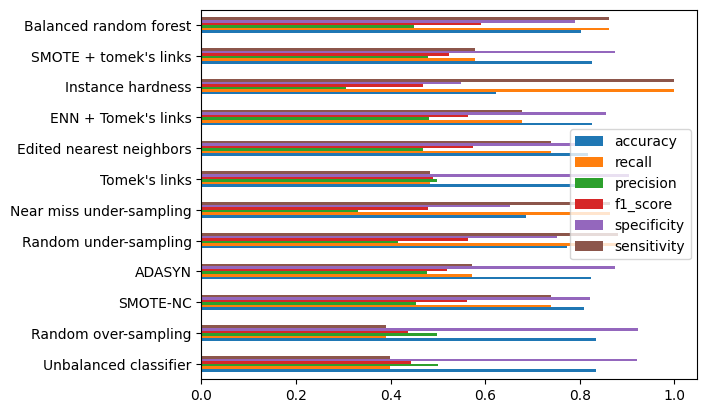

In [24]:
from pandas import DataFrame

VANILLA_METRICS = ml_pipeline(data, None, False, None)

METRICS = DataFrame([
    VANILLA_METRICS, RANDOM_OVER_SAMPLING_METRICS, SMOTE_SAMPLING_METRICS, ADASYN_SAMPLING_METRICS, RANDOM_UNDERSAMPLING_METRICS, NEAR_MISS_UNDERSAMPLING_METRICS,
    TOMEK_UNDERSAMPLING_METRICS, ENN_UNDERSAMPLING_METRICS, NEIGHBORHOOD_UNDERSAMPLING_METRICS, HARDNESS_UNDERSAMPLING_METRICS, SMOTE_TOMEK_METRICS,
    BALANCED_FOREST_METRICS
], index=["Unbalanced classifier", "Random over-sampling", "SMOTE-NC", "ADASYN", "Random under-sampling", "Near miss under-sampling", "Tomek's links",
           "Edited nearest neighbors", "ENN + Tomek's links", "Instance hardness", "SMOTE + tomek's links", "Balanced random forest"])

METRICS.plot.barh()